In [2]:
# %% load environment
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
from torch.utils.data import DataLoader

join = os.path.join
import torch

from skimage import io, transform
import torch.nn.functional as F

from pytorch_ood.detector import Mahalanobis
from pytorch_ood.utils import OODMetrics

import monai
from monai.metrics import DiceMetric



from utils.util_swinlitemedsam import ( 
    MedSAM_Lite,
    resize_longest_side,
    pad_image,
    MedSAM_infer_npz_2D,
    resize_box_to_256,
    get_points_256,
    get_scribble_256,
    medsam_inference
)


from models import (PromptEncoder, TwoWayTransformer, SwinTransformer, MaskDecoder_Prompt)

PROJECT_ROOT="/home/jovyan/thesis_project/"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from utils.dep_injection_util import (
        BaseDataset,
        BBoxFromMask,
        NpzLoader
)

In [13]:
import numpy as np
from monai.transforms import MapTransform

class RepeatChannelNumpyd(MapTransform):
    def __init__(self, keys, repeats=3, to_channel_last=True):
        super().__init__(keys)
        self.repeats = repeats
        self.to_channel_last = to_channel_last

    def __call__(self, data):
        d = dict(data)

        for key in self.keys:
            x = d[key]

            # Ensure channel-first
            if x.ndim == 2:
                x = x[None, ...]  # (H, W) -> (1, H, W)

            # Repeat channels if needed
            if x.shape[0] == 1:
                x = np.repeat(x, self.repeats, axis=0)  # (C, H, W)

            # Convert to channel-last if requested
            if self.to_channel_last:
                x = np.transpose(x, (1, 2, 0))  # (H, W, C)

            d[key] = x.astype(np.uint8, copy=False)

        return d
    

    

class CropByBBoxd(MapTransform):
    def __init__(self, keys, bbox_key="bbox", padding=0):
        super().__init__(keys)
        self.bbox_key = bbox_key
        self.padding = padding

    def __call__(self, data):
        d = dict(data)

        bbox = d[self.bbox_key]
        if isinstance(bbox, list):
            bbox = bbox[0]

        x_min, y_min, x_max, y_max = bbox.astype(int)

        # assume image/mask are H x W or H x W x C
        ref = d[self.keys[0]]
        H, W = ref.shape[:2]

        x_min = max(0, x_min - self.padding)
        y_min = max(0, y_min - self.padding)
        x_max = min(W, x_max + self.padding)
        y_max = min(H, y_max + self.padding)

        for key in self.keys:
            x = d[key]

            if x.ndim == 2:
                d[key] = x[y_min:y_max, x_min:x_max]
            elif x.ndim == 3:
                d[key] = x[y_min:y_max, x_min:x_max, :]
            else:
                raise ValueError(f"Unsupported shape for {key}: {x.shape}")

        d["crop_bbox"] = np.array([x_min, y_min, x_max, y_max], dtype=np.int32)

        # adjust bbox to cropped space
        new_bbox = np.array([
            bbox[0] - x_min,
            bbox[1] - y_min,
            bbox[2] - x_min,
            bbox[3] - y_min,
        ], dtype=np.int32)

        d["bbox"] = [new_bbox]

        return d    




data_transform=monai.transforms.Compose([
                    RepeatChannelNumpyd(keys=["image"], repeats=3, to_channel_last=True),
                    CropByBBoxd(keys=["image", "mask"], bbox_key="bbox", padding=20)
                    #monai.transforms.EnsureChannelFirstd(keys=['image', 'mask'], channel_dim="no_channel"),
                    # monai.transforms.RandFlipd(keys=['img', 'mask'], prob=1, spatial_axis=1),
                    # monai.transforms.RandRotated(keys=['img', 'mask'], range_x=np.pi/4, prob=1, mode=['bilinear', 'nearest'])
                    ])

In [14]:
dataset_path = Path(PROJECT_ROOT + "/datasets/INbreast/INbreast Release 1.0/")

id_dicom_dir = dataset_path / "MassCases"
ood_dicom_dir = dataset_path / "NoMassCases"

loader = NpzLoader(dtype=np.uint8)

bbox_generator = BBoxFromMask(
    annotation_threshold=0.5,
    bbox_padding=0,
    allow_empty_mask=False
)


id_dataset = BaseDataset(
    root=id_dicom_dir,
    format_loader=loader,
    transforms=data_transform,
    bbox_generator=bbox_generator
)

ood_dataset = BaseDataset(
    root=ood_dicom_dir,
    format_loader=loader,
    transforms=data_transform,
    bbox_generator=bbox_generator,
    label=-1
)


In [11]:
device="cpu"
lite_medsam_checkpoint_path="./Swin_LiteMedSAM.pth"

medsam_lite_image_encoder = SwinTransformer()

medsam_lite_prompt_encoder = PromptEncoder(embed_dim=256,
                                           image_embedding_size=(64, 64),
                                           input_image_size=(256, 256),
                                           mask_in_chans=16)

medsam_lite_mask_decoder = MaskDecoder_Prompt(
    num_multimask_outputs=3,
    transformer=TwoWayTransformer(
        depth=2,
        embedding_dim=256,
        mlp_dim=2048,
        num_heads=8,
    ),
    transformer_dim=256,
    iou_head_depth=3,
    iou_head_hidden_dim=256,
)

medsam_lite_model = MedSAM_Lite(image_encoder=medsam_lite_image_encoder,
                                mask_decoder=medsam_lite_mask_decoder,
                                prompt_encoder=medsam_lite_prompt_encoder)

lite_medsam_checkpoint = torch.load(lite_medsam_checkpoint_path,
                                    map_location='cpu')
try:
    medsam_lite_model.load_state_dict(lite_medsam_checkpoint)
except:
    try:
        medsam_lite_model.load_state_dict(lite_medsam_checkpoint['model'])
    except Exception as e:
        print(e)
        raise ValueError("Failed to load the checkpoint")

medsam_lite_model.to(device)
medsam_lite_model.eval()

MedSAM_Lite(
  (image_encoder): SwinTransformer(
    (patch_embed): PatchEmbed(
      (seq): Sequential(
        (0): Conv2d_BN(
          (c): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): GELU(approximate='none')
        (2): Conv2d_BN(
          (c): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
    )
    (stage1): BasicLayer(
      (downsample): PatchMerging(
        (patch_merge): Unfold(kernel_size=2, dilation=1, padding=0, stride=2)
        (linear): Linear(in_features=256, out_features=128, bias=True)
      )
      (blocks): ModuleList(
        (0): ModuleList(
          (0): SwinBlock(
            (attention_block): Residual(
              (fn): PreNorm(
                (norm): LayerNorm((128,), eps=1e-05, elementwise

### OOD detection

In [14]:
# Pass ID data through encoder and fit Mahalanobis distance metric
feats_list_id = []
labels_list_id = []


def preprocess_img(img, device):
    img=resize_longest_side(img,256)
    img=(img - img.min()) / np.clip(
        img.max() - img.min(), a_min=1e-8, a_max=None)
    img=pad_image(img, 256)
    img=torch.tensor(img).float().permute(
        2, 0, 1).unsqueeze(0).to(device)
    return img
    



with torch.no_grad():
    for sample in id_dataset:
        
        img = sample["image"]    
        img= preprocess_img(img,device)
        
        y = sample["label"].to(device).long()
        
        
        
        
        z, _ = medsam_lite_model.image_encoder(img)              # [B, C, H, W] feature maps
        z = z.mean(dim=(2, 3))                     # [B, C] global average pool

        feats_list_id.append(z)
        labels_list_id.append(y)

Z_id = torch.cat(feats_list_id, dim=0)
Y_id = torch.stack(labels_list_id, dim=0)

detector = Mahalanobis(model=None)
detector.fit_features(Z_id, Y_id)

No device given. Will use 'cpu'.


In [18]:
# Predict on OOD dataset
feats_list_ood = []

with torch.no_grad():
    for sample in ood_dataset:
        img = sample["image"]
        img= preprocess_img(img,device)
        z,_ = medsam_lite_model.image_encoder(img)
        z = z.mean(dim=(2, 3))
        feats_list_ood.append(z)

Z_ood = torch.cat(feats_list_ood, dim=0)


scores_id = detector.predict_features(Z_id)
scores_ood = detector.predict_features(Z_ood)

In [19]:
# 1) Make label tensors (same length as scores)
y_id  = torch.zeros(len(scores_id), dtype=torch.long)        # ID label = 0
y_ood = -torch.ones(len(scores_ood), dtype=torch.long)       # OOD label = -1

# 2) Concatenate
scores = torch.cat([scores_id.detach().cpu(), scores_ood.detach().cpu()], dim=0)
y_true = torch.cat([y_id, y_ood], dim=0)

# 3) Compute metrics
metrics = OODMetrics()
metrics.update(scores, y_true)
result = metrics.compute()

print(result)

{'AUROC': 1.0, 'AUTC': 0.33562976121902466, 'AUPR-IN': 1.0000001192092896, 'AUPR-OUT': 1.0, 'FPR95TPR': 0.0}


### Segmentation

In [15]:
pred_masks_metrics = []

dice_metric = DiceMetric(
    include_background=True,
    reduction="mean"
)


for i, sample in enumerate(id_dataset):
        
    sample_gt = sample["mask"]
    
    # # skip if mask is empty
    # if np.sum(sample_gt) == 0:
    #     continue

    pred_mask, iou = MedSAM_infer_npz_2D(
        sample,
        device=device,
        medsam_lite_model=medsam_lite_model
    )

    pred = torch.from_numpy(pred_mask).unsqueeze(0).unsqueeze(0)
    gt = torch.from_numpy(sample_gt).unsqueeze(0).unsqueeze(0)

    pred = (pred > 0).float()
    gt = (gt > 0).float()

    dice = dice_metric(y_pred=pred, y=gt)

    pred_masks_metrics.append((sample_gt, pred_mask, dice.item(), iou))

box:[ 20  20 137 153]
box:[ 20  20 388 275]
box:[  6  20 345 307]
box:[ 20  20 682 784]
box:[ 20  20 774 824]
box:[  0  20 308 268]
box:[ 20  20 206 181]
box:[ 20  20 473 625]
box:[ 20  20 287 361]
box:[20 20 95 90]
box:[ 20  20 106  82]
box:[ 20  20 332 339]
box:[ 20  20 202 223]
box:[ 20  20 340 317]
box:[ 20  20 513 634]
box:[ 20  20 185 156]
box:[ 20  20 451 501]
box:[ 20  20 302 276]
box:[ 20  20 942 746]
box:[ 20  20 505 451]
box:[ 20  20 562 607]
box:[ 20  20 385 511]
box:[ 20  20 478 600]
box:[ 20  20 168 244]
box:[ 20  20 472 594]
box:[ 20  20 613 728]
box:[ 20  20 521 621]
box:[ 20  20 169 171]
box:[ 20  20 158 122]
box:[ 20  20 329 349]
box:[ 20  20 561 613]
box:[  1  20 349 464]
box:[ 20  20 238 225]
box:[ 20  20 194 183]
box:[ 20  20 267 324]
box:[ 20  20 517 385]
box:[ 20  20 204 223]
box:[ 20  20 227 242]
box:[ 20  20 478 350]
box:[ 20  20 548 279]
box:[ 20  20 266 259]
box:[ 20  20 409 449]
box:[ 20  20 196 253]
box:[ 20  20 611 686]
box:[ 20  20 317 370]
box:[ 20  20 3

In [16]:
for i in range(len(pred_masks_metrics)):
    print(pred_masks_metrics[i][-2])



0.8373375535011292
0.7535073161125183
0.9177253842353821
0.922721803188324
0.9223045706748962
0.9341170191764832
0.7736954092979431
0.9188686609268188
0.9070031046867371
0.6456876397132874
0.7560758590698242
0.934033215045929
0.585414707660675
0.8277846574783325
0.914749026298523
0.21074829995632172
0.9249748587608337
0.9236510992050171
0.9020084142684937
0.9613980054855347
0.841130793094635
0.9073818922042847
0.9078667759895325
0.837985098361969
0.9751037955284119
0.8478501439094543
0.8034106492996216
0.7933259606361389
0.6413552165031433
0.9189329743385315
0.7416623830795288
0.9054350852966309
0.9160128831863403
0.824492871761322
0.854097306728363
0.9146828651428223
0.8966482877731323
0.9432026147842407
0.8098528385162354
0.8436809778213501
0.9335296154022217
0.9287307858467102
0.8552792072296143
0.75423663854599
0.9359482526779175
0.9322043061256409
0.7690943479537964
0.9521530866622925
0.9321323037147522
0.9051812291145325
0.89698326587677
0.9117165803909302
0.7319989800453186
0.90

TypeError: 'NoneType' object is not subscriptable

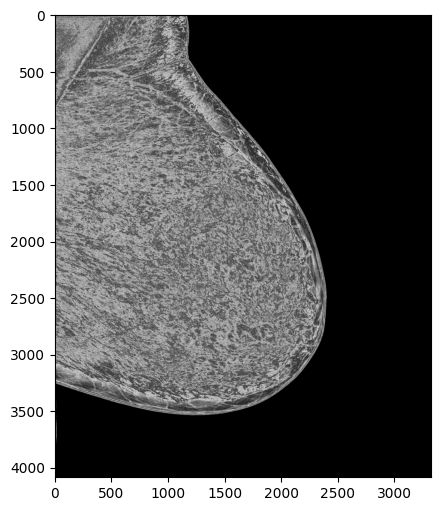

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def show_bbox_overlay(image, bbox, gt_mask=None, pred_mask=None):
    """
    Overlay bbox (+ optional masks) on an image.

    bbox: np.array([x_min, y_min, x_max, y_max])
    """

    fig, ax = plt.subplots(1, figsize=(6, 6))

    # Show image (if provided)
    if image is not None:
        ax.imshow(image, cmap="gray")

    # Optional: GT mask (green)
    if gt_mask is not None:
        gt = np.zeros((*gt_mask.shape, 4))
        gt[..., 1] = gt_mask
        gt[..., 3] = gt_mask * 0.4
        ax.imshow(gt)

    # Optional: Pred mask (red)
    if pred_mask is not None:
        pred = np.zeros((*pred_mask.shape, 4))
        pred[..., 0] = pred_mask
        pred[..., 3] = pred_mask * 0.4
        ax.imshow(pred)

    # Draw bbox
    x_min, y_min, x_max, y_max = bbox[0]
    width = x_max - x_min
    height = y_max - y_min

    rect = patches.Rectangle(
        (x_min, y_min),
        width,
        height,
        linewidth=2,
        edgecolor="blue",
        facecolor="none"
    )

    ax.add_patch(rect)

    ax.set_title("BBox + Masks Overlay")
    ax.axis("off")
    plt.show()

sample=id_dataset[23]
    
img=sample["image"]
bbox=sample["bbox"]
gt_mask_sample = sample["mask"]
pred_mask_sample = pred_masks_metrics[0][1]



show_bbox_overlay(
    image=img,           # or your original image if you have it
    bbox=bbox,
    gt_mask=gt_mask_sample,
    pred_mask=None
)